In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.io.arff import loadarff 
import seaborn as sns

#### dataset source
https://www.openml.org/search?type=data&sort=runs&id=1590&status=active

In [2]:
data, metadata = loadarff('../datasets/adult_census.arff')
adult_census = pd.DataFrame(data)
for col in adult_census.select_dtypes(include='object'):
    adult_census[col] = adult_census[col].str.decode('utf-8')
adult_census.dtypes.unique()

array([dtype('float64'), <StringDtype(storage='python', na_value=nan)>],
      dtype=object)

In [3]:
# numerical columns
adult_census = adult_census[['age', 'capital-gain', 'capital-loss', 'hours-per-week', 'class']]
adult_census['age'].describe(), adult_census['capital-gain'].max()

(count    48842.000000
 mean        38.643585
 std         13.710510
 min         17.000000
 25%         28.000000
 50%         37.000000
 75%         48.000000
 max         90.000000
 Name: age, dtype: float64,
 np.float64(99999.0))

In [4]:
from sklearn.model_selection import train_test_split

X, y = adult_census.drop(columns='class'), adult_census['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
model.score(X_test, y_test)

0.7993612316763574

In [6]:
from sklearn.dummy import DummyClassifier

model_dummy = DummyClassifier(strategy='most_frequent')
model_dummy.fit(X_train, y_train)
model_dummy.score(X_test, y_test)

0.7607075587584964

#### data preprocessing

In [7]:
print(type(X_train.describe()))
before_scaling = X_train.describe().loc[['mean', 'std']]
before_scaling

<class 'pandas.DataFrame'>


,age,capital-gain,capital-loss,hours-per-week
mean,38.704321,1065.124812,89.449292,40.451830
std,13.734951,7381.066834,407.019994,12.386722


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
print(X_train_scaled.shape)
after_scaling = pd.DataFrame(
    np.vstack((np.mean(X_train_scaled, axis=0), np.std(X_train_scaled, axis=0))), 
    index=['mean', 'std'], columns=scaler.get_feature_names_out())
after_scaling

(36631, 4)


,age,capital-gain,capital-loss,hours-per-week
mean,4.151024e-17,1.319017e-17,9.310707e-18,2.203534e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [9]:
means = scaler.mean_
stds = scaler.scale_
X_train_scaled_manually = (X_train - means) / stds
np.mean(X_train_scaled_manually, axis=0)

age               4.151024e-17
capital-gain      1.319017e-17
capital-loss      9.310707e-18
hours-per-week    2.203534e-16
dtype: float64

In [10]:
# scaler outputing data frames
scaler_pd = StandardScaler().set_output(transform="pandas")
X_train_scaled_pd = scaler_pd.fit_transform(X_train)
X_train_scaled_pd

,age,capital-gain,capital-loss,hours-per-week
48403,0.749607,-0.144307,-0.219769,-0.036477
32075,-1.070592,-0.144307,-0.219769,-0.036477
17722,1.623303,-0.144307,-0.219769,-1.974063
16284,1.040839,-0.144307,-0.219769,-0.036477
21413,-1.143399,-0.144307,-0.219769,-0.440141
...,...,...,...,...
38827,0.458375,-0.144307,-0.219769,-0.036477
2621,-0.196896,0.844452,-0.219769,-0.682339
12701,0.603991,13.403919,-0.219769,-0.036477
20602,-0.488128,-0.144307,-0.219769,-0.036477


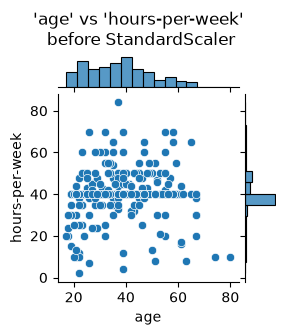

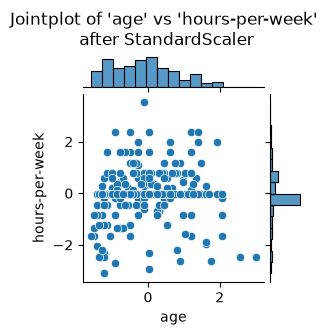

In [11]:
num_points_to_plot = 300
sns.jointplot(
    data=X_train[:num_points_to_plot], height=3,
    x="age", y="hours-per-week", marginal_kws=dict(bins=15))
plt.suptitle("'age' vs 'hours-per-week' \nbefore StandardScaler", y=1.1)
sns.jointplot(
    data=X_train_scaled_pd[:num_points_to_plot], height=3,
    x="age", y="hours-per-week", marginal_kws=dict(bins=15))
_ = plt.suptitle("Jointplot of 'age' vs 'hours-per-week' \nafter StandardScaler", y=1.1)

In [14]:
model.fit(X_train_scaled, y_train)
X_test_scaled = scaler.transform(X_test)
model.score(X_test_scaled, y_test)

0.7990336581770535

### pipeline

In [53]:
from sklearn.pipeline import Pipeline

pipe = Pipeline(steps=[('scaler', StandardScaler()), ('clf', LogisticRegression())], verbose=True)
pipe.fit(X_train, y_train)
print(pipe.score(X_test, y_test))
pipe.named_steps['clf'].coef_

[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing clf, total=   0.2s
0.7990336581770535


array([[0.52149706, 2.40364158, 0.31327182, 0.53042839]])

In [ ]:
y_pred_prob = pipe.predict_proba(X_test)
# picking only the points model is sure about
idx_include = np.where(np.abs(y_pred_prob[:, 0]-y_pred_prob[:, 1])>=0.7)
pipe.score(X_test.iloc[idx_include], y_test.iloc[idx_include])

0.9361254541977434

In [61]:
print(pipe.named_steps)
pipe

{'scaler': StandardScaler(), 'clf': LogisticRegression()}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('clf', ...)]"
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",True
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['<=50K','>50K']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['age','capital-gain','capital-loss','hours-per-week']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [69]:
import time
print('\tcomparing fitting time on scaled and non-scaled data\n')
model = LogisticRegression()
start = time.time()
model.fit(X_train, y_train)
print(f'Non-scaled data: {(time.time()-start):.3f} s')
start = time.time()
model.fit(X_train_scaled, y_train)
print(f'Scaled data: {(time.time()-start):.3f} s')

	comparing fitting time on scaled and non-scaled data

Non-scaled data: 0.346 s
Scaled data: 0.101 s
